obs, actions: 4, 2
Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=2, bias=True)
)
0 14.289212226867676 17.66666603088379
1 16.446063995361328 19.490385055541992
2 17.87371063232422 21.69565200805664
3 23.213977813720703 24.439023971557617
4 20.61977195739746 23.390243530273438
5 26.866365432739258 28.700000762939453
6 22.866413116455078 25.4743595123291
7 27.959779739379883 25.657533645629883
8 31.43379020690918 35.50877380371094
9 31.77181053161621 33.576271057128906
10 27.872573852539062 33.220340728759766
11 33.70938491821289 40.87234115600586
12 25.987478256225586 35.745452880859375
13 40.1223258972168 48.846153259277344
14 33.896175384521484 40.934783935546875
15 35.20981216430664 44.83333206176758
16 34.6390495300293 45.13953399658203
17 40.344058990478516 50.53845977783203
18 39.720481872558594 46.95000076293945
19 39.64234161376953 53.91428756713867
20 37.391151428222656 51.864864349365234
21 47.8987

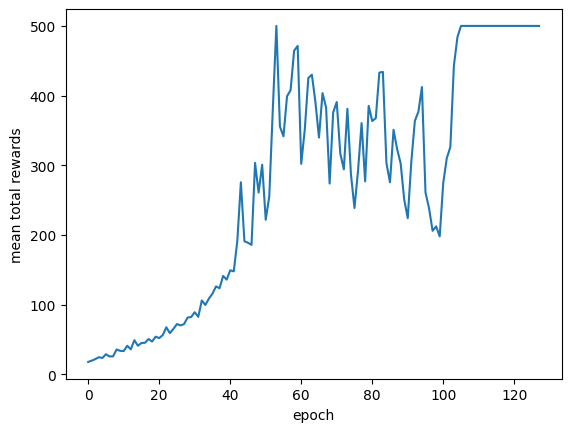

In [1]:
import torch
from torch import nn
from torch.optim import AdamW
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


def build_mlp(sizes: list[int]):
    layers = []
    for i in range(len(sizes)-1):
        layers.append(nn.Linear(sizes[i], sizes[i+1]))
        if i != len(sizes) - 2: layers.append(nn.ReLU())
    return nn.Sequential(*layers)


N_EPOCHS = 128
BATCH_SIZE = 2048
DEVICE = "cpu"

N_ENVS = 4
envs = gym.make_vec("CartPole-v1", num_envs=N_ENVS, vectorization_mode="sync")
N_OBS = envs.single_observation_space.shape[0]
N_ACTIONS = int(envs.single_action_space.n)
print(f"obs, actions: {N_OBS}, {N_ACTIONS}")

policy = build_mlp([N_OBS, 32, N_ACTIONS])
policy.to(DEVICE)
print(policy)

optim = AdamW(policy.parameters(), lr=1e-2)

mean_total_rewards = []
for epoch in range(N_EPOCHS):
    idxs = np.arange(N_ENVS, dtype=np.int32)
    episode_reset = np.zeros(N_ENVS, dtype=np.bool)

    batch_logprobs = [[] for _ in range(N_ENVS)]
    batch_rewards = [[] for _ in range(N_ENVS)]
    full_ep = [0 for _ in range(N_ENVS)]

    n_samples = 0
    obs, _ = envs.reset()
    while n_samples < BATCH_SIZE:
        obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
        logits = policy(obs)

        action_dist = Categorical(logits=logits)
        actions = action_dist.sample()
        logprobs = action_dist.log_prob(actions)

        obs, rewards, terminated, truncated, _ = envs.step(actions.numpy())

        for i, idx in enumerate(idxs):
            if episode_reset[i]:
                continue

            batch_logprobs[idx].append(logprobs[i])
            batch_rewards[idx].append(rewards[i])
            n_samples += 1

            if terminated[i] or truncated[i]:
                idxs[i] = len(batch_logprobs)
                batch_logprobs.append([])
                batch_rewards.append([])
                full_ep[idx] = 1
                full_ep.append(0)

        episode_reset = terminated | truncated

    total_rewards = torch.tensor([sum(r) for r in batch_rewards], dtype=torch.float32)
    batch_rewards = torch.cat([torch.full((len(batch_rewards[i]),), fill_value=total_rewards[i], dtype=torch.float32, device=DEVICE) for i in range(len(total_rewards))])
    batch_logprobs = torch.cat([torch.stack(l) for l in batch_logprobs if l])

    # Optimize policy.
    loss = -(batch_logprobs * batch_rewards).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    # Log.
    full_ep = torch.tensor(full_ep, dtype=torch.float32)
    mean_total_reward = ((full_ep * total_rewards).sum() / full_ep.sum()).item()
    mean_total_rewards.append(mean_total_reward)
    print(epoch, loss.item(), mean_total_reward)

plt.plot(mean_total_rewards)
plt.xlabel("epoch")
plt.ylabel("mean total rewards")
plt.show()